In [ ]:
import os
import numpy as np
import cv2
from glob import glob
from tqdm import tqdm
import imageio
from albumentations import HorizontalFlip, VerticalFlip, Rotate

In [ ]:
np.random.seed(42)

In [ ]:
import zipfile

with zipfile.ZipFile('data.zip', 'r') as zip_ref:
    zip_ref.extractall('data')


In [ ]:
data_path = '/content/data'

In [ ]:
train_x = sorted(glob(os.path.join(data_path, 'data', 'train','images','*.tif')))

In [ ]:

for x in train_x:
  print(x)

/content/data/data/train/images/21_training.tif
/content/data/data/train/images/22_training.tif
/content/data/data/train/images/23_training.tif
/content/data/data/train/images/24_training.tif
/content/data/data/train/images/25_training.tif
/content/data/data/train/images/26_training.tif
/content/data/data/train/images/27_training.tif
/content/data/data/train/images/28_training.tif
/content/data/data/train/images/29_training.tif
/content/data/data/train/images/30_training.tif
/content/data/data/train/images/31_training.tif
/content/data/data/train/images/32_training.tif
/content/data/data/train/images/33_training.tif
/content/data/data/train/images/34_training.tif
/content/data/data/train/images/35_training.tif
/content/data/data/train/images/36_training.tif
/content/data/data/train/images/37_training.tif
/content/data/data/train/images/38_training.tif
/content/data/data/train/images/39_training.tif
/content/data/data/train/images/40_training.tif


In [ ]:
train_y = sorted(glob(os.path.join(data_path, 'data', 'train','1st_manual','*.gif')))

In [ ]:
test_x = sorted(glob(os.path.join(data_path, 'data', 'test','images','*.tif')))
test_y = sorted(glob(os.path.join(data_path, 'data', 'test','1st_manual','*.gif')))

In [ ]:
print(f"Train length {len(train_x)} - {len(train_y)}")
print(f"Test length {len(test_x)} - {len(test_y)}")

Train length 20 - 20
Test length 20 - 20


In [ ]:
#To save augmented data
newdata_train_image = os.makedirs(os.path.join('data', 'new_data', 'train', 'images'), exist_ok = True)
newdata_train_mask= os.makedirs(os.path.join('data', 'new_data', 'train', 'mask'), exist_ok = True)
newdata_test_image = os.makedirs(os.path.join('data', 'new_data', 'test', 'images'), exist_ok = True)
newdata_test_mask = os.makedirs(os.path.join('data', 'new_data', 'test', 'mask'), exist_ok = True)


In [ ]:
# Data augmentation
from pathlib import Path
def data_augment(images, mask, save_path, augment = True):
  size = (256, 256)
  for idx, (x,y) in enumerate(tqdm(zip(images, mask), total = len(images))):
    """ Extracting name """
    name = Path(x.split('/')[-1]).stem

    """ Reading image and mask """
    """ single gif has multiple frames , thats why used [0]
    which most common case to use first frame """
    x = cv2.imread(x , cv2.IMREAD_COLOR)
    y = imageio.mimread(y)[0]

    if augment == True:
      aug = HorizontalFlip(p = 1.0)
      augmented = aug(image = x, mask = y)
      x1 = augmented["image"]
      y1 = augmented["mask"]

      aug = VerticalFlip(p = 1.0)
      augmented = aug(image = x, mask = y)
      x2 = augmented["image"]
      y2 = augmented["mask"]

      aug = Rotate(limit = 45, p = 1.0)
      augmented = aug(image = x, mask = y)
      x3 = augmented["image"]
      y3 = augmented["mask"]

      X = [x, x1, x2, x3]
      Y = [y, y1, y2, y3]
    else:
      X = [x]
      Y = [y]

    for index, (i,m) in enumerate(zip(X, Y)):
      i = cv2.resize(i, size)
      m = cv2.resize(m, size, interpolation=cv2.INTER_NEAREST)
      temp_image = f"{name}_{index}.png"
      temp_mask = f"{name}_{index}.png"

      img_path = os.path.join(save_path,"images", temp_image)
      mask_path = os.path.join(save_path,"mask", temp_mask)

      cv2.imwrite(img_path, i)
      cv2.imwrite(mask_path, m)

In [ ]:
#!pip install imagecodecs

In [ ]:
data_augment(train_x, train_y, 'data/new_data/train', augment = True)
data_augment(test_x, test_y, 'data/new_data/test', augment = False)

100%|██████████| 20/20 [00:00<00:00, 25.06it/s]


In [ ]:
# import shutil

# # Deletes the directory and everything inside it
# shutil.rmtree('/content/data/new_data')


In [ ]:
# UNET model archtecture
import torch
import torch.nn as nn

class conv_block(nn.Module):
  def __init__(self, in_c, out_c, kernel_size = 3, padding = 1):
    super().__init__()
    self.conv1 = nn.Conv2d(in_c, out_c, kernel_size, padding = padding)
    self.bn1 = nn.BatchNorm2d(out_c)

    self.conv2 = nn.Conv2d(out_c, out_c, kernel_size, padding = padding)
    self.bn2 = nn.BatchNorm2d(out_c)


    self.relu = nn.ReLU()


  def forward(self, inputs):
    x = self.conv1(inputs)
    x = self.bn1(x)
    x = self.relu(x)

    x = self.conv2(x)
    x = self.bn2(x)
    x = self.relu(x)


    return x


In [ ]:
class encoder_block(nn.Module):
  def __init__(self, in_c, out_c):
    super().__init__()

    self.conv = conv_block(in_c, out_c)
    self.pool = nn.MaxPool2d((2, 2))

  def forward(self, inputs):
    x = self.conv(inputs)
    p = self.pool(x)

    return x, p

In [ ]:
class decoder_block(nn.Module):
  def __init__(self, in_c, out_c):
    super().__init__()

    self.up = nn.ConvTranspose2d(in_c, out_c, kernel_size = 2, stride = 2, padding = 0)
    self.conv = conv_block(out_c + out_c, out_c)


  def forward(self, inputs, skip):
    x = self.up(inputs)
    x = torch.cat([x, skip], axis =1)
    x = self.conv(x)

    return x


In [ ]:
class build_unet(nn.Module):
  def __init__(self):
    super().__init__()

    """ Encoder """
    self.en1 = encoder_block(3, 32)
    self.en2 = encoder_block(32, 64)
    self.en3 = encoder_block(64, 128)
    self.en4 = encoder_block(128, 256)

    """ Bottleneck """
    self.bottleneck = conv_block(256, 512)

    """ Decoder """
    self.d1 = decoder_block(512, 256)
    self.d2 = decoder_block(256, 128)
    self.d3 = decoder_block(128, 64)
    self.d4 = decoder_block(64, 32)

    """ Classification """
    self.outputs = nn.Conv2d(32, 1, kernel_size= 1, padding=0)

  def forward(self, inputs):
    s1, p1 = self.en1(inputs)
    s2, p2 = self.en2(p1)
    s3, p3 = self.en3(p2)
    s4, p4 = self.en4(p3)

    b = self.bottleneck(p4)

    d1 = self.d1(b, s4)
    d2 = self.d2(d1, s3)
    d3 = self.d3(d2, s2)
    d4 = self.d4(d3, s1)

    outputs = self.outputs(d4)

    return outputs

In [ ]:
x = torch.randn((2, 3, 256, 256))
f = build_unet()
y = f(x)
print(y.shape)


torch.Size([2, 1, 256, 256])


In [ ]:
import torch.nn.functional as F

class DiceLoss(nn.Module):
  def __init__(self, weight = None, size_average = True):
    super(DiceLoss, self).__init__()

  def forward(self, inputs, targets, smooth=1):
    inputs = torch.sigmoid(inputs)

    inputs = inputs.view(-1)
    targets = targets.view(-1)

    intersection = (inputs * targets).sum()
    dice = (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)

    return 1 - dice


class DiceBCELoss(nn.Module):
    def __init__(self, pos_weight=None):
        super(DiceBCELoss, self).__init__()
        self.pos_weight = pos_weight

    def forward(self, inputs, targets, smooth=1):
        inputs_sig = torch.sigmoid(inputs)

        # Dice Loss
        inputs_flat  = inputs_sig.view(-1)
        targets_flat = targets.view(-1)
        intersection = (inputs_flat * targets_flat).sum()
        dice_loss = 1 - (2. * intersection + smooth) / (inputs_flat.sum() + targets_flat.sum() + smooth)

        # Weighted BCE Loss
        BCE = F.binary_cross_entropy_with_logits(
            inputs, targets,
            pos_weight=self.pos_weight
        )

        return BCE + dice_loss

In [ ]:
from torch.utils.data import DataLoader, Dataset
# Load dataset
train_x = sorted(glob('/content/data/new_data/train/images/*'))
train_y = sorted(glob('/content/data/new_data/train/mask/*'))

test_x = sorted(glob('/content/data/new_data/test/images/*'))
test_y = sorted(glob('/content/data/new_data/test/mask/*'))

In [ ]:
#Hyperparameters
H = 256
W = 256
size = (H, W)
batch_size = 2
num_epochs = 80
lr = 1e-4

In [ ]:
# Dataset and Loader
class DriveDataset(Dataset):
  def __init__(self, images_path, mask_path):
    self.images_path = images_path
    self.mask_path = mask_path
    self.n_samples = len(images_path)

  def __getitem__(self, index):
    """ Reading image """
    image = cv2.imread(self.images_path[index], cv2.IMREAD_COLOR)
    image = image/255.0  #512, 512, 3
    image = np.transpose(image, (2, 0, 1)) #3, 512, 512, 512
    image = image.astype(np.float32)
    image = torch.from_numpy(image)

    """ Reading mask """
    mask = cv2.imread(self.mask_path[index], cv2.IMREAD_GRAYSCALE)
    mask = mask/255.0
    mask = np.expand_dims(mask, axis = 0)
    mask = mask.astype(np.float32)
    mask = torch.from_numpy(mask)

    return image, mask

  def __len__(self):
    return self.n_samples

In [ ]:
print(f"Train length {len(train_x)} - {len(train_y)}")
print(f"Test length {len(test_x)} - {len(test_y)}")


Train length 80 - 80
Test length 20 - 20


In [ ]:
train_dataset = DriveDataset(train_x, train_y)
train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = batch_size,
    shuffle = True,
    num_workers = 0
    )

test_dataset = DriveDataset(test_x, test_y)
test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = batch_size,
    shuffle = False,
    num_workers = 0
    )

In [ ]:
model = build_unet()
optimizer = torch.optim.Adam(model.parameters(), lr= lr)

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience = 5)
pos_weight = torch.tensor([1195995 / 114725])  # 10.4
loss_fn = DiceBCELoss()

In [ ]:
def train(model, loader, optimizer, loss_fn):
    epoch_loss = 0.0
    correct = 0
    total = 0
    model.train()

    for x, y in loader:
        optimizer.zero_grad()
        y_pred = model(x)
        loss = loss_fn(y_pred, y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * x.size(0)

        # Accuracy
        preds = (torch.sigmoid(y_pred) > 0.5).float()
        correct += (preds == y).sum().item()
        total   += y.numel()

    return epoch_loss / len(loader), correct / total

In [ ]:
def evaluate(model, loader, loss_fn):
    epoch_loss = 0.0
    correct = 0
    total = 0
    model.eval()

    with torch.no_grad():
        for x, y in loader:
            y_pred = model(x)
            loss = loss_fn(y_pred, y)

            epoch_loss += loss.item() * x.size(0)

            # Accuracy
            preds = (torch.sigmoid(y_pred) > 0.5).float()
            correct += (preds == y).sum().item()
            total   += y.numel()

    return epoch_loss / len(loader), correct / total

In [ ]:
x, y = next(iter(train_loader))
print(x.shape, y.shape)

torch.Size([2, 3, 256, 256]) torch.Size([2, 1, 256, 256])


In [ ]:
# Training loop
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

In [32]:
for epoch in tqdm(range(num_epochs), desc="Training Progress"):
    train_loss, train_acc = train(model, train_loader, optimizer, loss_fn)
    valid_loss, valid_acc = evaluate(model, test_loader, loss_fn)
    scheduler.step(valid_loss)

    train_losses.append(train_loss)
    val_losses.append(valid_loss)
    train_accs.append(train_acc)
    val_accs.append(valid_acc)

    tqdm.write(f"Epoch {epoch+1}: Train loss={train_loss:.4f} | Train acc={train_acc:.4f} | Val loss={valid_loss:.4f} | Val acc={valid_acc:.4f}")


Training Progress:   1%|▏         | 1/80 [02:43<3:35:20, 163.55s/it]

Epoch 1: Train loss=3.1299 | Train acc=0.3980 | Val loss=3.0570 | Val acc=0.6797


Training Progress:   2%|▎         | 2/80 [05:18<3:25:41, 158.22s/it]

Epoch 2: Train loss=2.7754 | Train acc=0.7286 | Val loss=2.7424 | Val acc=0.7826


Training Progress:   4%|▍         | 3/80 [07:49<3:18:55, 155.01s/it]

...

Epoch 62: Train loss=0.4289 | Train acc=0.9928 | Val loss=1.0258 | Val acc=0.9577


Training Progress:  79%|███████▉  | 63/80 [2:37:27<42:37, 150.42s/it]

Epoch 63: Train loss=0.4125 | Train acc=0.9931 | Val loss=1.0231 | Val acc=0.9577


Training Progress:  79%|███████▉  | 63/80 [2:38:10<42:41, 150.65s/it]


KeyboardInterrupt: 

In [33]:
torch.save({
    'epoch':        epoch,
    'model_state':  model.state_dict(),
    'optimizer_state': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses':   val_losses,
    'train_accs':   train_accs,
    'val_accs':     val_accs,
}, 'checkpoint.pth')

print("Model saved!")

Model saved!


In [36]:
import matplotlib.pyplot as plt


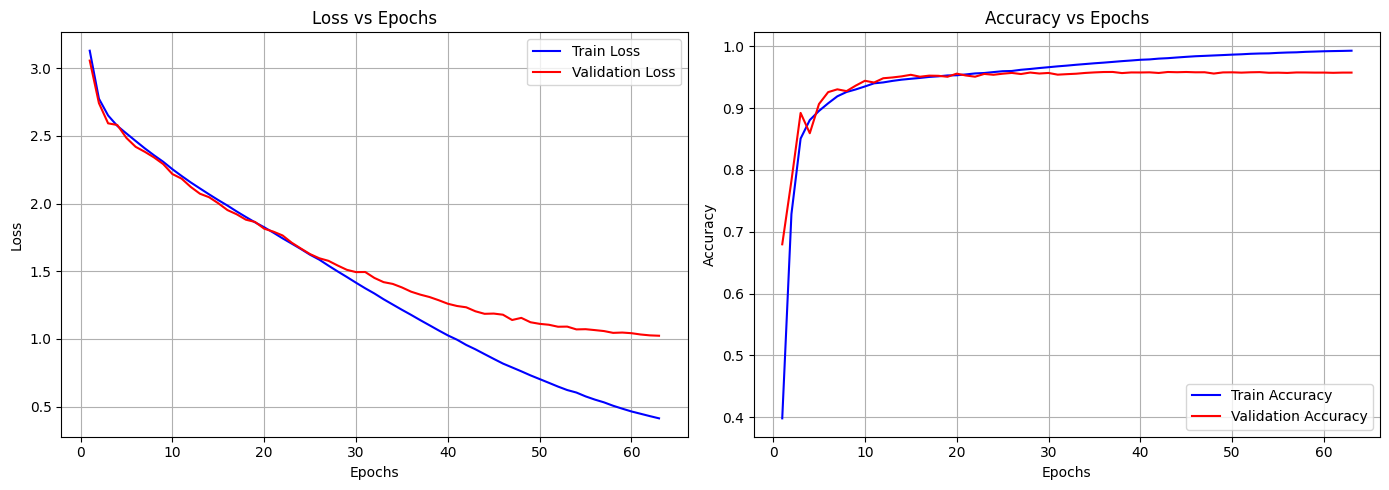

In [39]:
epochs_ran = len(train_losses)

# Plot loss and accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, epochs_ran+1), train_losses, label='Train Loss',      color='blue')
axes[0].plot(range(1, epochs_ran+1), val_losses,   label='Validation Loss', color='red')
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(range(1, epochs_ran+1), train_accs, label='Train Accuracy',      color='blue')
axes[1].plot(range(1, epochs_ran+1), val_accs,   label='Validation Accuracy', color='red')
axes[1].set_title('Accuracy vs Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [43]:
from sklearn.metrics import f1_score, jaccard_score, accuracy_score

def calculate_metrics(y_true, y_pred):
    y_pred = (torch.sigmoid(y_pred) > 0.5).float()

    y_true = y_true.view(-1).cpu().numpy()
    y_pred = y_pred.view(-1).cpu().numpy()

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    iou = jaccard_score(y_true, y_pred, zero_division=0)
    return acc, f1, iou

# Run on test set
model.eval()
all_acc, all_f1, all_iou = [], [], []

with torch.no_grad():
    for x, y in test_loader:
        y_pred = model(x)
        acc, f1, iou = calculate_metrics(y, y_pred)
        all_acc.append(acc)
        all_f1.append(f1)
        all_iou.append(iou)

print(f"Accuracy: {np.mean(all_acc):.4f}")
print(f"F1/Dice:  {np.mean(all_f1):.4f}")
print(f"IoU:      {np.mean(all_iou):.4f}")

Accuracy: 0.9579
F1/Dice:  0.7437
IoU:      0.5922


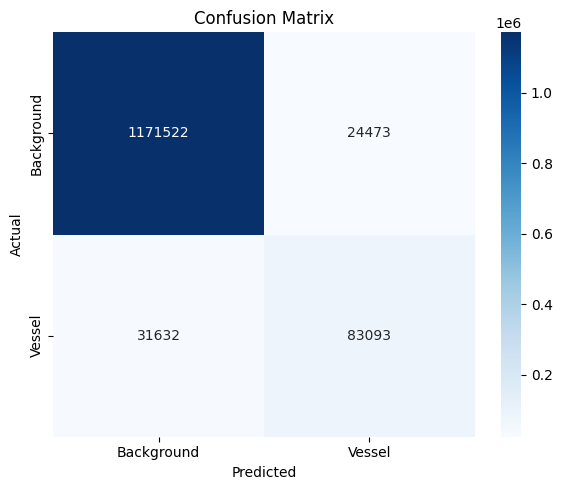

              precision    recall  f1-score   support

  Background       0.97      0.98      0.98   1195995
      Vessel       0.77      0.72      0.75    114725

    accuracy                           0.96   1310720
   macro avg       0.87      0.85      0.86   1310720
weighted avg       0.96      0.96      0.96   1310720



In [44]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:
        y_pred = model(x)
        y_pred = (torch.sigmoid(y_pred) > 0.3).float()
        all_preds.append(y_pred.view(-1).cpu().numpy())
        all_targets.append(y.view(-1).cpu().numpy())

all_preds   = np.concatenate(all_preds).astype(int)
all_targets = np.concatenate(all_targets).astype(int)

# Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Background', 'Vessel'],
            yticklabels=['Background', 'Vessel'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Metrics
print(classification_report(all_targets, all_preds,
                             target_names=['Background', 'Vessel']))

In [45]:
from sklearn.metrics import jaccard_score

jaccard = jaccard_score(all_targets, all_preds)
print(f"Jaccard / IoU Score: {jaccard:.4f}")

Jaccard / IoU Score: 0.5969


In [46]:
torch.save(model.state_dict(), "unet_retina.pth")

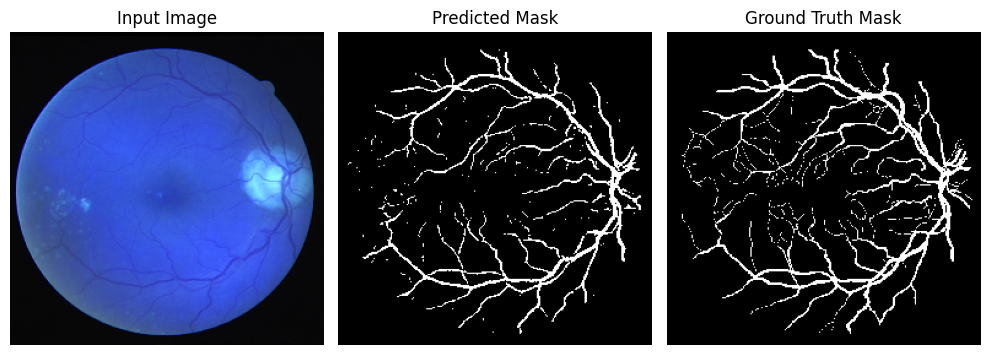

In [57]:
def predict_single(model, image, device):
    image_path = os.path.join(f"/content/data/new_data/test/images/{image}")
    mask_path = os.path.join(f"/content/data/new_data/test/mask/{image}")

    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)


    image = cv2.resize(image, (256, 256))

    input_tensor = torch.from_numpy(
        np.transpose(image / 255.0, (2, 0, 1))
    ).float().unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output    = model(input_tensor)
        pred_mask = (torch.sigmoid(output) > 0.5).float()

    fig, axes = plt.subplots(1, 3, figsize=(10, 5))
    axes[0].imshow(image)
    axes[0].set_title('Input Image')
    axes[0].axis('off')

    axes[1].imshow(pred_mask.squeeze().cpu().numpy(), cmap='gray')
    axes[1].set_title('Predicted Mask')
    axes[1].axis('off')


    axes[2].imshow(mask, cmap = 'grey')
    axes[2].set_title('Ground Truth Mask')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Usage
predict_single(model, '08_test_0.png', torch.device('cpu'))